# Deutsch–Jozsa Algorithm(DJA) with Rotation gate

In realistic quantum systems, qubits can be affected by noise during the computation.  
To study this in the DJA, we introduce single-qubit rotation errors at different points of the algorithm.

We consider rotation errors applied to a single qubit along one of the Pauli axes R(n) 

1. Before the first H affects the initial superposition  
2. After the first H  affects the superposed state before the oracle  
3. After the oracle U_f affects the phase-amplified state  
4. After the final H affects the final interference pattern before measurement  

In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [2]:
# =========================
# Single-case test with shots
# =========================

shots = 1024
n = 1
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

f_const = qa.deutsch_jozsa.f_constant_0
f_bal = qa.deutsch_jozsa.f_balanced_parity

cases = {
    "No Error": qa.deutsch_jozsa.deutsch_jozsa,
    r"$\mathcal{E}_1$": qa.deutsch_jozsa.deutsch_jozsa_error1,
    r"$\mathcal{E}_2$": qa.deutsch_jozsa.deutsch_jozsa_error2,
    r"$\mathcal{E}_3$": qa.deutsch_jozsa.deutsch_jozsa_error3,
    r"$\mathcal{E}_4$": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

labels = []
constant_probs = []
balanced_probs = []

for label, func in cases.items():

    if label == "No Error":
        state_c = func(n, f_const)
        state_b = func(n, f_bal)
    else:
        state_c = func(n, f_const, theta, target_qubit, axis)
        state_b = func(n, f_bal, theta, target_qubit, axis)

    samples_c = qa.deutsch_jozsa.sample_measurements_input(state_c, n, shots)
    samples_b = qa.deutsch_jozsa.sample_measurements_input(state_b, n, shots)

    P0_c = samples_c[0] / shots
    P0_b = samples_b[0] / shots

    labels.append(label)
    constant_probs.append(P0_c)
    balanced_probs.append(P0_b)

    print(label)
    print("constant P(0):", P0_c)
    print("balanced P(0):", P0_b)
    print()

No Error
constant P(0): 1.0
balanced P(0): 0.0

$\mathcal{E}_1$
constant P(0): 0.87109375
balanced P(0): 0.13671875

$\mathcal{E}_2$
constant P(0): 1.0
balanced P(0): 0.0

$\mathcal{E}_3$
constant P(0): 1.0
balanced P(0): 0.0

$\mathcal{E}_4$
constant P(0): 0.8447265625
balanced P(0): 0.1494140625



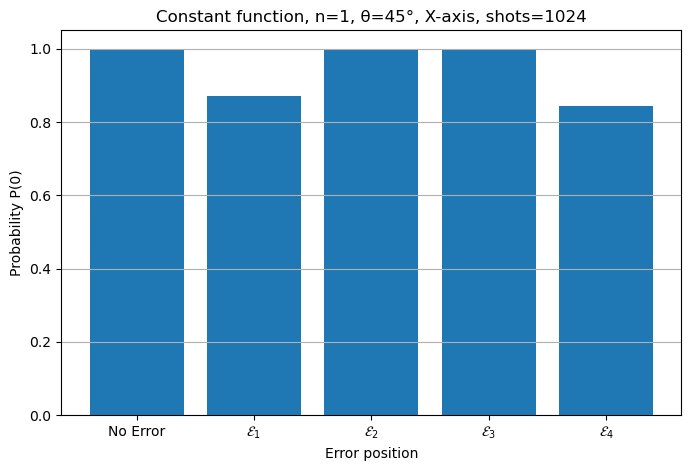

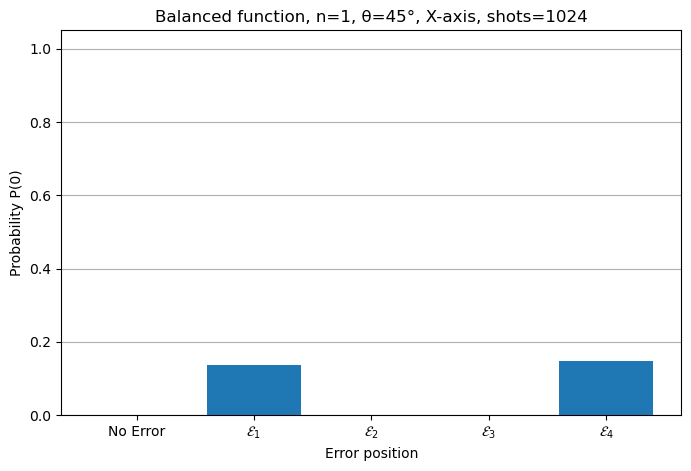

In [3]:
plt.figure(figsize=(8, 5))
plt.bar(labels, constant_probs)
plt.ylim(0, 1.05)
plt.xlabel("Error position")
plt.ylabel("Probability P(0)")
plt.title("Constant function, n=1, θ=45°, X-axis, shots=1024")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(labels, balanced_probs)
plt.ylim(0, 1.05)
plt.xlabel("Error position")
plt.ylabel("Probability P(0)")
plt.title("Balanced function, n=1, θ=45°, X-axis, shots=1024")
plt.grid(axis="y")
plt.show()

Original DJA
P(0) c: 0.9999999999999996
P(0) b: 1.0573994819069698e-33

DJA with E1 (before H)
P(0) c: 0.853553390593273
P(0) b: 0.14644660940672613

DJA with E2 (after first H)
P(0) c: 0.9999999999999992
P(0) b: 6.624483918491784e-36

DJA with E3 (after oracle)
P(0) c: 0.9999999999999992
P(0) b: 6.624483918491784e-36

DJA with E4 (after final H)
P(0) c: 0.8535533905932733
P(0) b: 0.14644660940672619


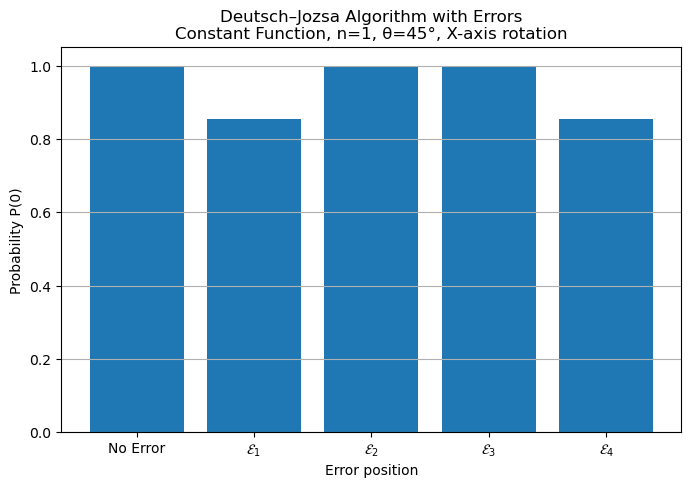

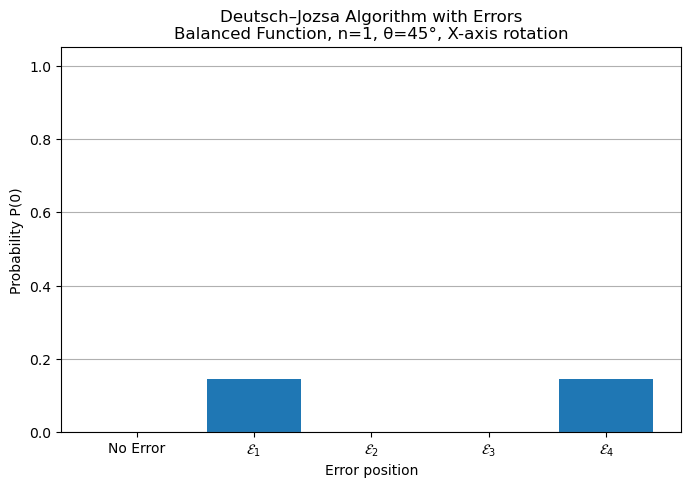

Running n = 1
Running n = 3
Running n = 5
Running n = 7


In [ ]:
# Parameters
n = 1
theta = np.pi / 4        
target_qubit = 0         
axis = (1, 0, 0)         


# Original Deutsch–Jozsa (no error)
const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_0)
bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
probs_c = qa.deutsch_jozsa.measure_probs_first_n(const, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(bal, n)

print("Original DJA")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()


# Error 1 (before Hadamards)
state_c1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c1, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b1, n)

print("DJA with E1 (before H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()

# Error 2 (after first Hadamards)
state_c2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c2, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b2, n)

print("DJA with E2 (after first H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()

# Error 3 (after oracle)
state_c3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c3, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b3, n)

print("DJA with E3 (after oracle)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()

# Error 4 (after final Hadamards)
state_c4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c4, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b4, n)

print("DJA with E4 (after final H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])

labels = [
    "No Error",
    r"$\mathcal{E}_1$",
    r"$\mathcal{E}_2$",
    r"$\mathcal{E}_3$",
    r"$\mathcal{E}_4$",
]

constant_probs = [
    1.0,  # Original constant result
    qa.deutsch_jozsa.measure_probs_first_n(state_c1, n)[0],
    qa.deutsch_jozsa.measure_probs_first_n(state_c2, n)[0],
    qa.deutsch_jozsa.measure_probs_first_n(state_c3, n)[0],
    qa.deutsch_jozsa.measure_probs_first_n(state_c4, n)[0],
]

balanced_probs = [
    0.0,  # Original balanced result
    qa.deutsch_jozsa.measure_probs_first_n(state_b1, n)[0],
    qa.deutsch_jozsa.measure_probs_first_n(state_b2, n)[0],
    qa.deutsch_jozsa.measure_probs_first_n(state_b3, n)[0],
    qa.deutsch_jozsa.measure_probs_first_n(state_b4, n)[0],
]

plt.figure(figsize=(8,5))

plt.bar(labels, constant_probs)

plt.ylim(0, 1.05)

plt.xlabel("Error position")
plt.ylabel("Probability P(0)")
plt.title(
    "Deutsch–Jozsa Algorithm with Errors\n"
    "Constant Function, n=1, θ=45°, X-axis rotation"
)

plt.grid(axis="y")

plt.show()

plt.figure(figsize=(8,5))

plt.bar(labels, balanced_probs)

plt.ylim(0, 1.05)

plt.xlabel("Error position")
plt.ylabel("Probability P(0)")
plt.title(
    "Deutsch–Jozsa Algorithm with Errors\n"
    "Balanced Function, n=1, θ=45°, X-axis rotation"
)

plt.grid(axis="y")

plt.show()

# =========================
# Experiment settings
# =========================

shots = 1024

n_values = [1, 3, 5, 7, 9]

theta_values = np.radians(np.arange(0, 181, 10))

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "balanced_parity": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

label_map = {
    "no_error": "No Error",
    "E1_before_H": r"$\mathcal{E}_1$",
    "E2_after_first_H": r"$\mathcal{E}_2$",
    "E3_after_oracle": r"$\mathcal{E}_3$",
    "E4_after_final_H": r"$\mathcal{E}_4$",
}

# =========================
# Run simulation with shots
# =========================

results = []

for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        # Original DJA without error
        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)
        samples_ref = qa.deutsch_jozsa.sample_measurements_input(
            state_ref, n, shots
        )

        P0_ref = samples_ref[0] / shots

        for theta in theta_values:
            for axis_name, axis in axes.items():

                results.append({
                    "n": n,
                    "theta_rad": theta,
                    "theta_deg": np.degrees(theta),
                    "axis": axis_name,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": "no_error",
                    "P0": P0_ref,
                    "shots": shots,
                })

                # E1, E2, E3, E4
                for error_name, error_function in error_positions.items():

                    state_error = error_function(
                        n, f, theta, target_qubit, axis
                    )

                    samples_error = qa.deutsch_jozsa.sample_measurements_input(
                        state_error, n, shots
                    )

                    P0_error = samples_error[0] / shots

                    results.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": np.degrees(theta),
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "function": function_name,
                        "error_position": error_name,
                        "P0": P0_error,
                        "shots": shots,
                    })

df = pd.DataFrame(results)

df.head()

In [ ]:
n = 1
theta = np.pi / 2       
target_qubit = 0         
axis = (0, 0, 1)         

# no error
con = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_0)
bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(con, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(bal, n)

print("no error")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])

# Error 1 before Hadamards
state_c1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c1, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b1, n)

print("E1 (before H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()


# Error 2 after first Hadamards.
state_c2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c2, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b2, n)

print("E2 (after first H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()


# Error 3, after oracle
state_c3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c3, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b3, n)

print("E3 after oracle")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()


# Error after final Hadamards
state_c4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c4, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b4, n)

print("E4 after final H")
print("P(0) c:\n", probs_c[0])
print("P(0) b:\n", probs_b[0])

In [ ]:
n = 2
theta = np.pi / 4        
target_qubit = 1       
axis = (1, 0, 0)         

# Original Deutsch–Jozsa (no error)
const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_0)
bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
probs_c = qa.deutsch_jozsa.measure_probs_first_n(const, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(bal, n)

print("Original DJA")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()


# Error 1 (before Hadamards)
state_c1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c1, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b1, n)

print("DJA with E1 (before H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()

# Error 2 (after first Hadamards)
state_c2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c2, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b2, n)

print("DJA with E2 (after first H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()

# Error 3 (after oracle)
state_c3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c3, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b3, n)

print("DJA with E3 (after oracle)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])
print()

# Error 4 (after final Hadamards)
state_c4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_0, theta, target_qubit, axis)
state_b4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

probs_c = qa.deutsch_jozsa.measure_probs_first_n(state_c4, n)
probs_b = qa.deutsch_jozsa.measure_probs_first_n(state_b4, n)

print("DJA with E4 (after final H)")
print("P(0) c:", probs_c[0])
print("P(0) b:", probs_b[0])

In [ ]:
shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)

samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("no errors")
print("cons:", samples_const)
print("bal:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_c2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_b2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_c2 = qa.deutsch_jozsa.sample_measurements_input(state_c2, n, shots)
samples_b2   = qa.deutsch_jozsa.sample_measurements_input(state_b2, n, shots)

print("Error 2 (after first Hadamards)")
print("sample for c2:", samples_c2)
print("sample for b2:", samples_b2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_c4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_b4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_c4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_b4, n, shots)

print("after final Hadamards")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 3
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)
print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()
state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)
print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 8
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 7
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)

samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 2000
n = 11
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)

samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 2000
n = 11
theta = np.pi / 4
target_qubit = 5
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 2000
n = 11
theta = np.pi / 4
target_qubit = 10
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()

state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 3000
n = 7
theta = np.pi / 4
target_qubit = 5
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 7000
n = 6
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()

state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 10000
n = 9
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 10000
n = 9
theta = np.pi / 4
target_qubit = 5
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)
samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

In [ ]:
shots = 10000
n = 9
theta = np.pi / 4
target_qubit = 8
axis = (1, 0, 0)

state_const = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_constant_1)
state_bal   = qa.deutsch_jozsa.deutsch_jozsa(n, qa.deutsch_jozsa.f_balanced_parity)

samples_const = qa.deutsch_jozsa.sample_measurements_input(state_const, n, shots)
samples_bal   = qa.deutsch_jozsa.sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal1   = qa.deutsch_jozsa.deutsch_jozsa_error1(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const1 = qa.deutsch_jozsa.sample_measurements_input(state_const1, n, shots)
samples_bal1   = qa.deutsch_jozsa.sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal2   = qa.deutsch_jozsa.deutsch_jozsa_error2(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const2 = qa.deutsch_jozsa.sample_measurements_input(state_const2, n, shots)
samples_bal2   = qa.deutsch_jozsa.sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal3   = qa.deutsch_jozsa.deutsch_jozsa_error3(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const3 = qa.deutsch_jozsa.sample_measurements_input(state_const3, n, shots)
samples_bal3   = qa.deutsch_jozsa.sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_constant_1, theta, target_qubit, axis)
state_bal4   = qa.deutsch_jozsa.deutsch_jozsa_error4(n, qa.deutsch_jozsa.f_balanced_parity, theta, target_qubit, axis)
samples_const4 = qa.deutsch_jozsa.sample_measurements_input(state_const4, n, shots)
samples_bal4   = qa.deutsch_jozsa.sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

### Simulating Measurements

The missing element of our quantum computer simulator is the measurement step. In the case we considered above, the output state was always one of the states of the computational basis, i.e. a "classical state" (and not entangled), but in general we end up with superpositions and the outcome of a measurement is random. This randomness we also want to implement in our quantum computer simulator. To do so, we can calculate the probabilities of all basis states and then randomly choose one of these outcomes according to this distribution. Write a function that takes a state $|\psi\rangle$ (i.e. its coefficient vector in the computational basis) as input and outputs one of the computational basis states as the measurement result. You may find the functions `random.rand` and `cumsum` from numpy helpful. 

Test your function on some example states, for example you could create an equal superposition of all basis states by applying Hadamard gates to all qubits.

Apply an $R_x$ rotation to single qubit initially in state $|0\rangle$ using various angles between 0 and $\pi$ and simulate $z$-basis meaurements. Evaluate the expectation value of $Z$ from these measuremets. For what angle are the statistical fluctuations compared to the exact expextation value the largest? 